# Trying to create and test U net 

# Arborescence de projet

In [52]:
import sys
import os
# On récupère le chemin absolu du dossier parent (..) et on l'ajoute au sys.path
dossier_parent = os.path.abspath('..')
if dossier_parent not in sys.path:
    sys.path.append(dossier_parent)

## Imports

In [53]:
import musdb
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import torchaudio
from u_net import UnetAudioStemmer
from tool_box.pad_or_crop import pad_or_crop_to_multiple
from IPython.display import Audio, display

## Data

In [54]:
data_base = "../data/dataset/"
mus = musdb.DB(root=data_base,is_wav=False)
track = mus.tracks[0]
X = torch.from_numpy(track.audio.T)
y = torch.from_numpy(track.targets["vocals"].audio.T)
if X.shape[0] > 1: 
        X = torch.mean(X,dim=0,keepdim=True)
if y.shape[0] > 1: 
        y = torch.mean(y,dim=0,keepdim=True)
sample_rate = track.rate
# On ne prends que 3 secondes du morceau 
X = X[:,30 * sample_rate : 33 * sample_rate]
y = y[:,30 * sample_rate : 33 * sample_rate]
print(f"🎵 Morceau chargé : {track.name}")
print(f"⏱️ Durée : {track.duration} secondes")

display(Audio(X, rate=sample_rate))
display(Audio(y,rate=sample_rate))


🎵 Morceau chargé : A Classic Education - NightOwl
⏱️ Durée : 171.24 secondes


# Constants

In [55]:
n_fft = 2048
hop_length = 512

# STFT Conversion 

In [56]:
X_stft = torch.stft(X,n_fft=n_fft,hop_length=hop_length,return_complex=True).unsqueeze(0)
y_stft = torch.stft(y,n_fft=n_fft,hop_length=hop_length,return_complex=True).unsqueeze(0)
print(X.shape)
X_stft = pad_or_crop_to_multiple(X_stft,multiple=8)
y_stft = pad_or_crop_to_multiple(y_stft,multiple=8)
print(X_stft.shape)

torch.Size([1, 132300])
torch.Size([1, 1, 1024, 256])


# Passage en DB pour normaliser entre les différents instruments. 

In [57]:
X_db = 20 * torch.log10(torch.abs(X_stft) + 1e-5)
y_db = 20 * torch.log10(torch.abs(y_stft) + 1e-5)
print(X_db.shape)

torch.Size([1, 1, 1024, 256])


# Correction pour normaliser sur les fréquences

In [58]:
X_db = X_db[..., :1024, :]
y_db= y_db[..., :1024, :]
print(X_db.shape)

torch.Size([1, 1, 1024, 256])


# Ajout d'une dimension pour le batch

In [59]:
X_train = X_db.float()
y_train = y_db.float()

print(f"📊 Shape de l'entrée X (Mix) : {X_train.shape}")
print(f"📊 Shape de la cible Y (Voix) : {y_train.shape}")

📊 Shape de l'entrée X (Mix) : torch.Size([1, 1, 1024, 256])
📊 Shape de la cible Y (Voix) : torch.Size([1, 1, 1024, 256])


# Init du modèle

In [60]:
model = UnetAudioStemmer()

# Utilisation de la L1 loss et pas la MSE car la L1 permet d'éviter que le modèle se focus sur les grosses valeurs gros pics d'énergie dans la musique alors que nous on veut éliminer le bruit ambiant autour de la voix.
criterion = nn.L1Loss()

# Optimizer 
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Paramètres de l'entraînement 

In [66]:
epochs = 10000 # On va répéter l'opération 50 fois sur le même extrait

# Entraînement

In [67]:
# Passer le modèle en mode train 
model.train()

for epoch in range(epochs):
    # Reset les gradients d'optimisation 
    optimizer.zero_grad()

    # Inference
    voice_spectogram = model(X_train)

    # Loss 
    loss = criterion(y_train, voice_spectogram)

    # Backward pass
    loss.backward()

    # Model Optimisation 
    optimizer.step()

    # Affichage de la progression tous les 10 epochs
    if (epoch + 1) % 10 == 0 or epoch == 0:
        print(f"Epoch [{epoch + 1}/{epochs}] - Loss : {loss.item():.4f}")

print("✅ Entraînement terminé !")
voice_spectogram = model(X_train)


Epoch [1/10000] - Loss : 14.3002
Epoch [10/10000] - Loss : 14.2637
Epoch [20/10000] - Loss : 14.2137
Epoch [30/10000] - Loss : 14.1481
Epoch [40/10000] - Loss : 14.1135
Epoch [50/10000] - Loss : 14.0907
Epoch [60/10000] - Loss : 14.0762
Epoch [70/10000] - Loss : 14.0638
Epoch [80/10000] - Loss : 14.0542
Epoch [90/10000] - Loss : 14.0383
Epoch [100/10000] - Loss : 14.0299
Epoch [110/10000] - Loss : 14.0266
Epoch [120/10000] - Loss : 14.0128
Epoch [130/10000] - Loss : 14.0050
Epoch [140/10000] - Loss : 13.9937
Epoch [150/10000] - Loss : 13.9795
Epoch [160/10000] - Loss : 14.0164
Epoch [170/10000] - Loss : 13.9883
Epoch [180/10000] - Loss : 13.9734
Epoch [190/10000] - Loss : 13.9588
Epoch [200/10000] - Loss : 13.9482
Epoch [210/10000] - Loss : 13.9374
Epoch [220/10000] - Loss : 13.9253
Epoch [230/10000] - Loss : 13.9108
Epoch [240/10000] - Loss : 13.8926
Epoch [250/10000] - Loss : 13.8740
Epoch [260/10000] - Loss : 13.8551
Epoch [270/10000] - Loss : 13.8491
Epoch [280/10000] - Loss : 13.8

# Test du sample

In [ ]:
# --- 1. NETTOYAGE DES DIMENSIONS ---
# On enlève les dimensions "Batch" et "Canal"
# Le tenseur passe de [1, 1, 1024, Temps] à [1024, Temps]
voice_spectogram = voice_spectogram.squeeze()
print(voice_spectogram.shape)

# --- 2. RETOUR À L'ÉCHELLE LINÉAIRE ---
# On inverse la formule des décibels ( 20 * log10(x) )
# On utilise detach() pour détacher le tenseur du graphe de calcul de PyTorch
voice_spectrogram_magnitude = 10 ** (voice_spectogram.detach() / 20)

#Récupération de la phase de la voix
y_phase = torch.angle(y_stft).squeeze()
print(y_phase.shape)

# On recrée un tenseur complexe (Magnitude + Phase) avec la formule d'Euler
complex_spec = voice_spectrogram_magnitude * torch.exp(1j * y_phase)

# ⚠️ 2. LA RUSTINE DU 1025 (Le rajout de la fréquence manquante) ⚠️
# complex_spec a la forme [1024, Temps]
# F.pad lit les dimensions à l'envers (de droite à gauche) :
# - Axe du Temps (dernière dimension) : on rajoute 0 avant, 0 après -> (0, 0)
# - Axe des Fréquences (avant-dernière) : on rajoute 0 avant, 1 après -> (0, 1)
complex_spec_padded = F.pad(complex_spec, (0, 0, 0, 1))

# On repasse dans le domaine temporel !
reconstructed_waveform = torch.istft(
    complex_spec_padded, 
    n_fft=n_fft, 
    hop_length=hop_length
)

# --- 6. ÉCOUTE DU RÉSULTAT ---
print("🎧 Résultat de la voix isolée par U-Net :")
# Assure-toi que la variable 'sample_rate' correspond bien à ton fichier audio (ex: 44100)
display(Audio(reconstructed_waveform.numpy(), rate=sample_rate))


torch.Size([1024, 256])
torch.Size([1024, 256])
🎧 Résultat de la voix isolée par ton U-Net :


# Comparaison spectro

In [71]:
import matplotlib.pyplot as plt

## Test

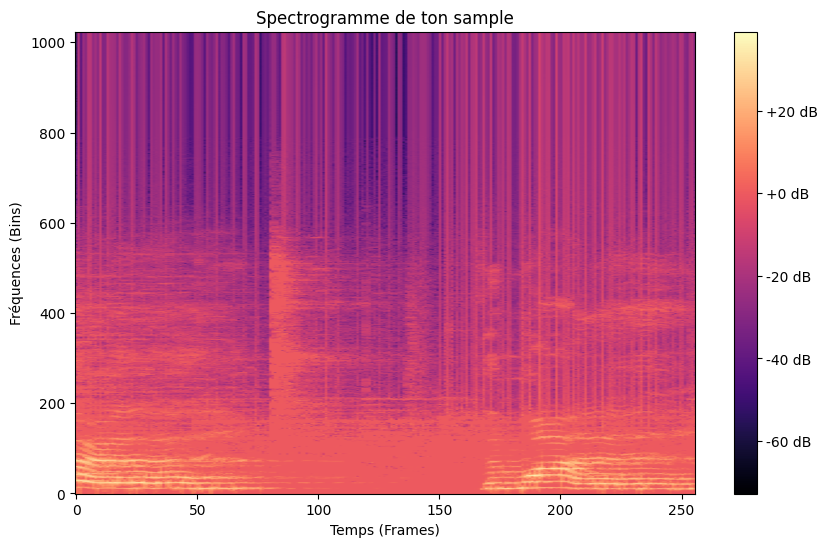

Dimension de l'image (Tenseur) : torch.Size([1024, 256])


In [78]:
plt.figure(figsize=(10, 6))
plt.imshow(voice_spectogram.detach(), origin='lower', aspect='auto', cmap='magma')
plt.title("Spectrogramme de ton sample")
plt.xlabel("Temps (Frames)")
plt.ylabel("Fréquences (Bins)")
plt.colorbar(format="%+2.0f dB")
plt.show()
print(f"Dimension de l'image (Tenseur) : {voice_spectogram.shape}")

## Vérité terrain

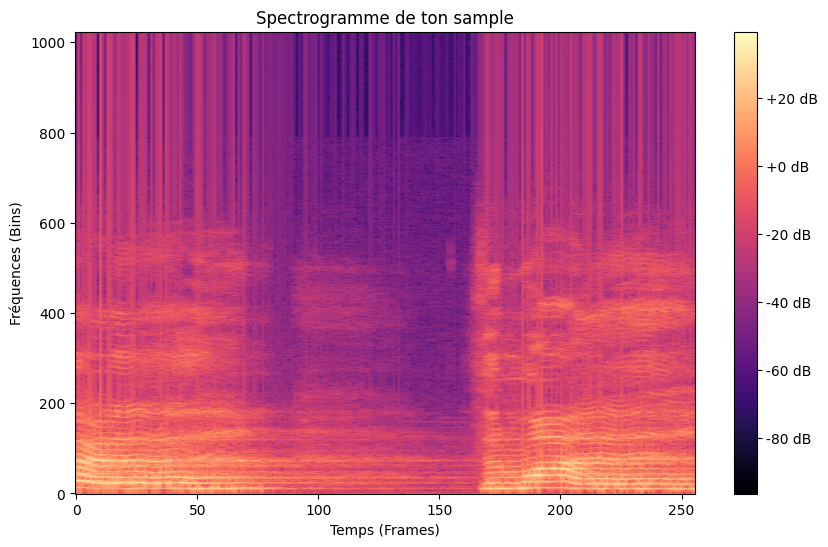

Dimension de l'image (Tenseur) : torch.Size([1024, 256])


In [79]:
plt.figure(figsize=(10, 6))
plt.imshow(y_train.squeeze().detach(), origin='lower', aspect='auto', cmap='magma')
plt.title("Spectrogramme de ton sample")
plt.xlabel("Temps (Frames)")
plt.ylabel("Fréquences (Bins)")
plt.colorbar(format="%+2.0f dB")
plt.show()
print(f"Dimension de l'image (Tenseur) : {voice_spectogram.shape}")